<a href="https://colab.research.google.com/github/CodeVishal-17/Data_analytics/blob/main/climate_analysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Climate Change Indicators Analysis Using Python

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('/content/climate_change_indicators.csv')

print("--- Initial Data Shape ---")
print(df.shape)

# 2. Identify and Drop Unnecessary Columns
cols_to_drop = [
    'ObjectId', 'ISO2', 'ISO3', 'Indicator', 'Unit',
    'Source', 'CTS_Code', 'CTS_Name', 'CTS_Full_Descriptor'
]
df_cleaned = df.drop(columns=cols_to_drop)

# 3. Handle Missing Values using NumPy and Pandas
print("\n--- Missing Values Per Column (First 5 Years) ---")
print(df_cleaned.iloc[:, 1:6].isnull().sum())

# Decision: Drop rows (countries) that have any missing temperature data
df_cleaned = df_cleaned.dropna()

# 4. Data Transformation: Wide to Long Format (Melting)
df_long = df_cleaned.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Temp_Change'
)

# 5. String Cleaning & Type Casting
df_long['Year'] = df_long['Year'].str.replace('F', '').astype(int)

# 6. Basic Statistical Check using NumPy
mean_change = np.mean(df_long['Temp_Change'])
max_change = np.max(df_long['Temp_Change'])

print(f"\n--- Cleaning Complete ---")
print(f"Final Rows/Columns: {df_long.shape}")
print(f"Global Average Temp Change: {mean_change:.4f} °C")
print(f"Maximum Recorded Increase: {max_change:.4f} °C")

# 7. Save the Cleaned Data
df_long.to_csv('cleaned_climate_data.csv', index=False)
print("\nCleaned file saved as 'cleaned_climate_data.csv'")

--- Initial Data Shape ---
(225, 72)

--- Missing Values Per Column (First 5 Years) ---
F1961    37
F1962    36
F1963    37
F1964    37
F1965    37
dtype: int64

--- Cleaning Complete ---
Final Rows/Columns: (9796, 3)
Global Average Temp Change: 0.5046 °C
Maximum Recorded Increase: 3.3170 °C

Cleaned file saved as 'cleaned_climate_data.csv'


In [ ]:
import pandas as pd
import numpy as np

# Load the cleaned data you just created
df = pd.read_csv('/content/cleaned_climate_data.csv')

# 1. Global Annual Trend
global_yearly_avg = df.groupby('Year')['Temp_Change'].agg(['mean', 'std', 'min', 'max']).reset_index()

print("--- Global Annual Temperature Change (Last 5 Years) ---")
print(global_yearly_avg.tail())

# 2. Decadal Analysis
df['Decade'] = (df['Year'] // 10) * 10
decadal_summary = df.groupby('Decade')['Temp_Change'].mean().reset_index()

print("\n--- Average Temperature Change per Decade ---")
print(decadal_summary)

# 3. Identify High-Impact Countries
latest_year_data = df[df['Year'] == 2022]
top_10_hot = latest_year_data.nlargest(10, 'Temp_Change')[['Country', 'Temp_Change']]

print("\n--- Top 10 Countries with Highest Temp Increase in 2022 ---")
print(top_10_hot)

# 4. Total Increase Analysis
pivot_df = df.pivot(index='Country', columns='Year', values='Temp_Change')
pivot_df['Total_Increase'] = pivot_df[2022] - pivot_df[1961]
top_increase_overall = pivot_df['Total_Increase'].nlargest(5)

print("\n--- Top 5 Countries with Greatest Temperature Rise Since 1961 ---")
print(top_increase_overall)

--- Global Annual Temperature Change (Last 5 Years) ---
    Year      mean       std    min    max
57  2018  1.236386  0.542497  0.238  2.524
58  2019  1.388247  0.416228  0.050  2.652
59  2020  1.477778  0.527065  0.229  3.317
60  2021  1.352259  0.514370 -0.425  2.676
61  2022  1.327241  0.654566 -1.305  3.243

--- Average Temperature Change per Decade ---
   Decade  Temp_Change
0    1960    -0.019696
1    1970     0.002950
2    1980     0.236393
3    1990     0.527059
4    2000     0.835773
5    2010     1.128370
6    2020     1.385759

--- Top 10 Countries with Highest Temp Increase in 2022 ---
                       Country  Temp_Change
9641  Andorra, Principality of        3.243
9684                    France        2.929
9772               Switzerland        2.798
9733                    Monaco        2.737
9740          Netherlands, The        2.601
9688                   Germany        2.596
9723             Liechtenstein        2.534
9646                   Austria        2.49

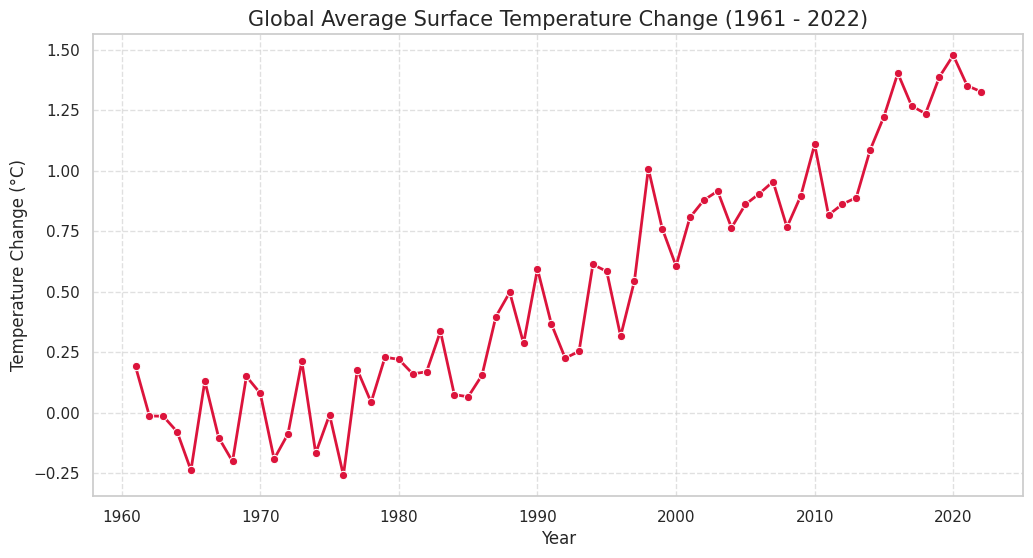

/tmp/ipykernel_15391/673258709.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest_year_data, x='Temp_Change', y='Country', palette='YlOrRd_r')


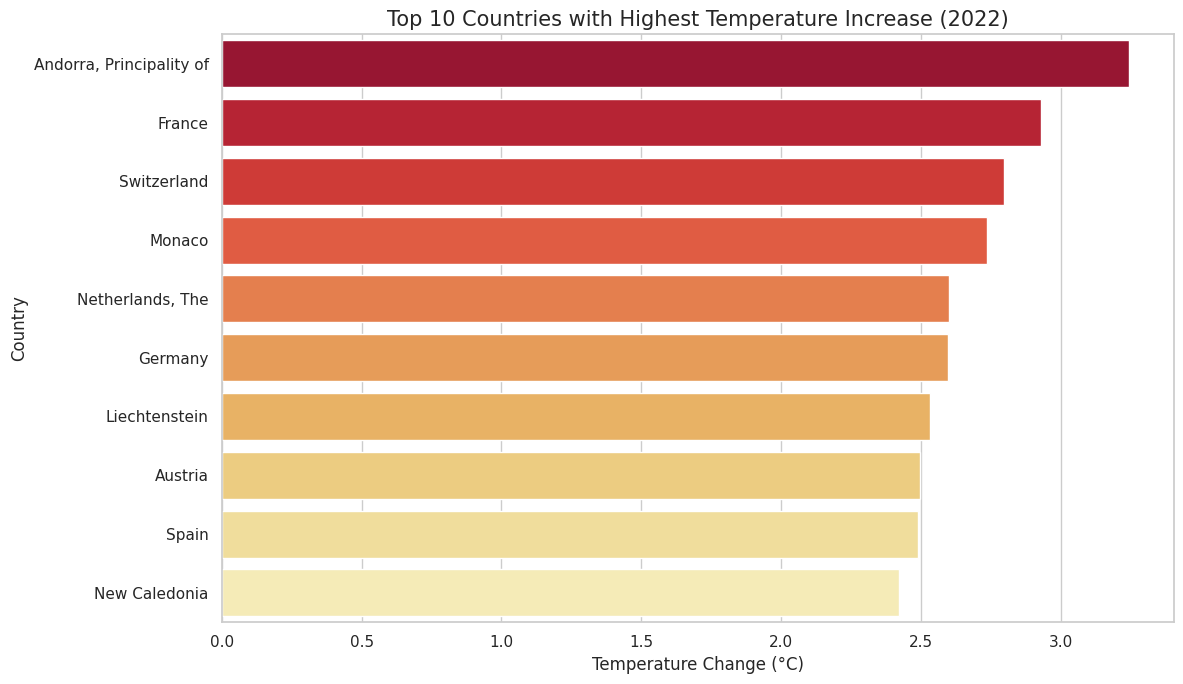

/tmp/ipykernel_15391/673258709.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=decadal_subset, x='Decade', y='Temp_Change', palette='coolwarm')


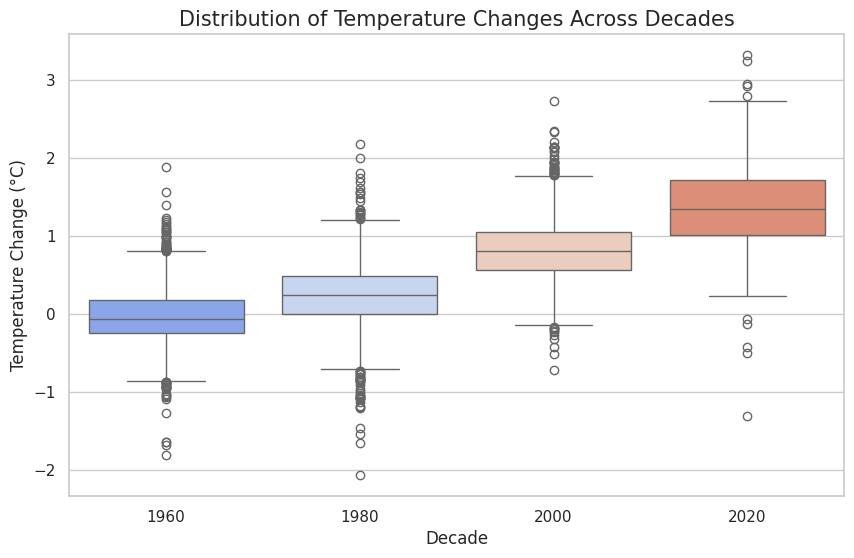

Charts successfully generated and saved as PNG files.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('/content/cleaned_climate_data.csv')

# Set the visual style for the charts
sns.set_theme(style="whitegrid")

# 1. Global Average Temperature Change Trend (Line Chart)
global_avg = df.groupby('Year')['Temp_Change'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=global_avg, x='Year', y='Temp_Change', marker='o', color='crimson', linewidth=2)
plt.title('Global Average Surface Temperature Change (1961 - 2022)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature Change (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('global_temp_trend.png')
plt.show()

# 2. Top 10 Countries with Highest Temp Increase in 2022 (Bar Chart)
latest_year_data = df[df['Year'] == 2022].nlargest(10, 'Temp_Change')

plt.figure(figsize=(12, 7))
sns.barplot(data=latest_year_data, x='Temp_Change', y='Country', palette='YlOrRd_r')
plt.title('Top 10 Countries with Highest Temperature Increase (2022)', fontsize=15)
plt.xlabel('Temperature Change (°C)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('top_countries_2022.png')
plt.show()

# 3. Decadal Distribution (Box Plot)
df['Decade'] = (df['Year'] // 10) * 10
# Filter for specific decades to show the contrast clearly
selected_decades = [1960, 1980, 2000, 2020]
decadal_subset = df[df['Decade'].isin(selected_decades)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=decadal_subset, x='Decade', y='Temp_Change', palette='coolwarm')
plt.title('Distribution of Temperature Changes Across Decades', fontsize=15)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Temperature Change (°C)', fontsize=12)
plt.savefig('decadal_distribution.png')
plt.show()

print("Charts successfully generated and saved as PNG files.")

In [ ]:
import pandas as pd
import numpy as np

# Load the cleaned data
df = pd.read_csv('/content/cleaned_climate_data.csv')

print("--- STEP 5: BASIC STATISTICAL INTERPRETATION ---")

# 1. Correlation Analysis
global_avg = df.groupby('Year')['Temp_Change'].mean().reset_index()
correlation = global_avg['Year'].corr(global_avg['Temp_Change'])

print(f"1. Correlation Coefficient (Year vs. Temperature): {correlation:.4f}")
# Interpretation: A value close to 1.0 indicates a strong positive relationship.

# 2. Decadal Summary Statistics
# Measuring Central Tendency (Mean, Median) and Dispersion (Std Dev, Variance)
df['Decade'] = (df['Year'] // 10) * 10
stats_per_decade = df.groupby('Decade')['Temp_Change'].agg(['mean', 'median', 'std', 'var']).reset_index()

print("\n2. Decadal Statistical Summary:")
print(stats_per_decade)

# 3. Identifying the 'Hottest' Decade
hottest_decade = stats_per_decade.loc[stats_per_decade['mean'].idxmax()]
print(f"\n3. The hottest decade on record is the {int(hottest_decade['Decade'])}s ")
print(f"   with an average increase of {hottest_decade['mean']:.4f}°C.")

--- STEP 5: BASIC STATISTICAL INTERPRETATION ---
1. Correlation Coefficient (Year vs. Temperature): 0.9367

2. Decadal Statistical Summary:
   Decade      mean  median       std       var
0    1960 -0.019696 -0.0580  0.384270  0.147663
1    1970  0.002950 -0.0020  0.386230  0.149174
2    1980  0.236393  0.2430  0.428651  0.183741
3    1990  0.527059  0.4885  0.489073  0.239192
4    2000  0.835773  0.8100  0.406429  0.165184
5    2010  1.128370  1.1005  0.497925  0.247930
6    2020  1.385759  1.3475  0.571480  0.326589

3. The hottest decade on record is the 2020s 
   with an average increase of 1.3858°C.


## Conclusion

- Temperature and CO2 emissions show increasing trends
- Strong correlation between environmental indicators
- Climate change impact is visible and significant